In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-03-13 15:53:26--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.223.14, 52.217.112.32, 52.217.135.144, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.223.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  15.9MB/s    in 0.8s    

2026-03-13 15:53:28 (15.9 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


## Importing data:

In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/working/jena_climate_2009_2016.csv')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
print("Headers/Columns in the dataset are as follows: \n", df.columns, '\n')
print("Number of samples: ", len(df))

Headers/Columns in the dataset are as follows: 
 Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object') 

Number of samples:  420451


each line is a timestep: a record of a date and 14 weather-related values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420451 entries, 0 to 420450
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420451 non-null  object 
 1   p (mbar)         420451 non-null  float64
 2   T (degC)         420451 non-null  float64
 3   Tpot (K)         420451 non-null  float64
 4   Tdew (degC)      420451 non-null  float64
 5   rh (%)           420451 non-null  float64
 6   VPmax (mbar)     420451 non-null  float64
 7   VPact (mbar)     420451 non-null  float64
 8   VPdef (mbar)     420451 non-null  float64
 9   sh (g/kg)        420451 non-null  float64
 10  H2OC (mmol/mol)  420451 non-null  float64
 11  rho (g/m**3)     420451 non-null  float64
 12  wv (m/s)         420451 non-null  float64
 13  max. wv (m/s)    420451 non-null  float64
 14  wd (deg)         420451 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


There are no null values, and all the columns except **Date Time** are of dtype **float64**,
next step will be separating temprature column from other columns and discarding Date Time column

## Prepraring data

In [5]:
feature_cols = ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)']


In [6]:
temperature = df['T (degC)'] #target
raw_data = df[feature_cols] #complete data including temprature, except Date Time column

## Plotting temprature timeseries:

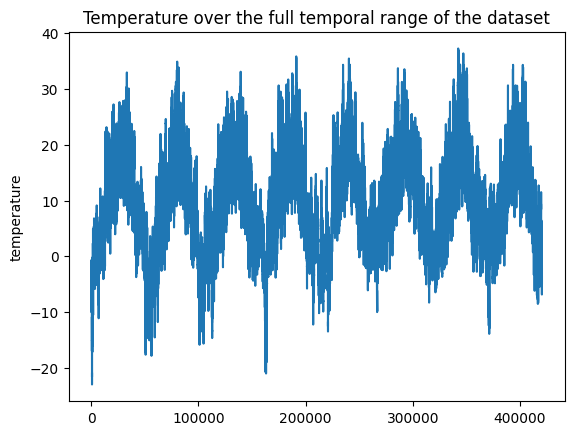

In [7]:
import matplotlib.pyplot as plt
plt.plot(range(len(temperature)), temperature)
plt.ylabel("temperature")
plt.title("Temperature over the full temporal range of the dataset")
plt.show()

Plotting the graph for first 10 days of data. 

Since the data is recorded every 10 min, we get 24 x 6 = 144 data point per day that is 1440 datapoints for 10 days.

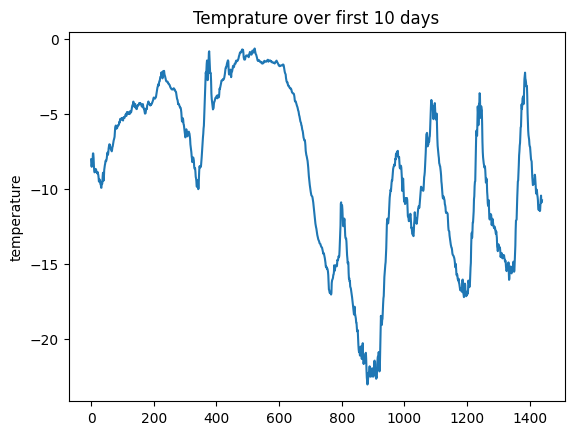

In [8]:
plt.plot(range(1440), temperature[:1440])
plt.ylabel("temperature")
plt.title("Temprature over first 10 days")
plt.show()

While using timeseries data we should always look for **periodicity** in the data. In the above plot we can see periodicity for the last 4 days.

We’ll use the first 50% of the data for training, the follow
ing 25% for validation, and the last 25% for testing. When working with timeseries
data, it’s important to use validation and test data that is more recent than the train
ing data, because you’re trying to predict the future given the past, not the reverse.

In [9]:
#Computing the number of samples we'll use for each data split

num_train_samples = int(0.5*(len(raw_data)))
num_val_samples = int(0.25*(len(raw_data)))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


## Preparing data:
Formulation of the problem will be as follows: given data covering the previous five days and sampled once per hour, can we predict the temperature in 24 hours?

First step will be to normalize the features, since all of them are on different scales. We'll compute **mean** and **std** on training samples.

In [10]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean

std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

## Creating dataset objects:
Creating a Dataset object that yields batches of data from the past five days
along with a target temperature 24 hours in the future. We'll use a built-in dataset utitlity in Keras '**timeseries_dataset_from_array()**' for this.

For example, if you use data = [0 1 2 3 4 5 6] and sequence_length=3, then
timeseries_dataset_from_array() will generate the following samples: [0 1 2],
[1 2 3], [2 3 4], [3 4 5], [4 5 6].

We’ll use the following parameter values:
* **sampling_rate**= 6—Observations will be sampled at one data point per hour:
we will only keep one data point out of 6.
* **sequence_length** = 120—Observations will go back 5 days (120 hours).
* **delay** = sampling_rate * (sequence_length + 24 - 1)—The target for a sequence
will be the temperature 24 hours after the end of the sequence.

In [11]:
from tensorflow import keras

sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)


2026-03-13 15:53:32.435685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773417212.618593      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773417212.667680      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773417213.095875      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773417213.095910      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773417213.095912      55 computation_placer.cc:177] computation placer alr

In [12]:
for samples, targets in train_dataset:
    print(samples.shape)
    print(targets.shape)
    break

(256, 120, 14)
(256,)


## Training a bseline DNN:

In [13]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(120, 14))
x = layers.Reshape((120*14,))(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_baseline.keras", save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history = model.fit(train_dataset,
                   epochs=10,
                   validation_data = val_dataset,
                   callbacks=callbacks)

Epoch 1/10


I0000 00:00:1773417240.756302     124 service.cc:152] XLA service 0x7a6bc4009120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773417240.756520     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773417240.925551     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


 11/819 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 79.2500 - mae: 7.0294

I0000 00:00:1773417241.442178     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - loss: 17.0973 - mae: 3.1305 - val_loss: 9.6514 - val_mae: 2.4455
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 9.1466 - mae: 2.3808 - val_loss: 10.9962 - val_mae: 2.6169
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 8.3213 - mae: 2.2690 - val_loss: 10.4730 - val_mae: 2.5615
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 7.7967 - mae: 2.1996 - val_loss: 12.8593 - val_mae: 2.8327
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 7.4985 - mae: 2.1550 - val_loss: 10.6200 - val_mae: 2.5759
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 7.2386 - mae: 2.1164 - val_loss: 11.9311 - val_mae: 2.7274
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 7.1095 - mae: 2.0982 - val_loss: 10.9546 - val_mae: 2.6141
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 6.9394 - mae: 2.0732 - val_loss: 10.9388 - val_mae: 2.6206
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,828 (210.27 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,915 (105.14 KB)

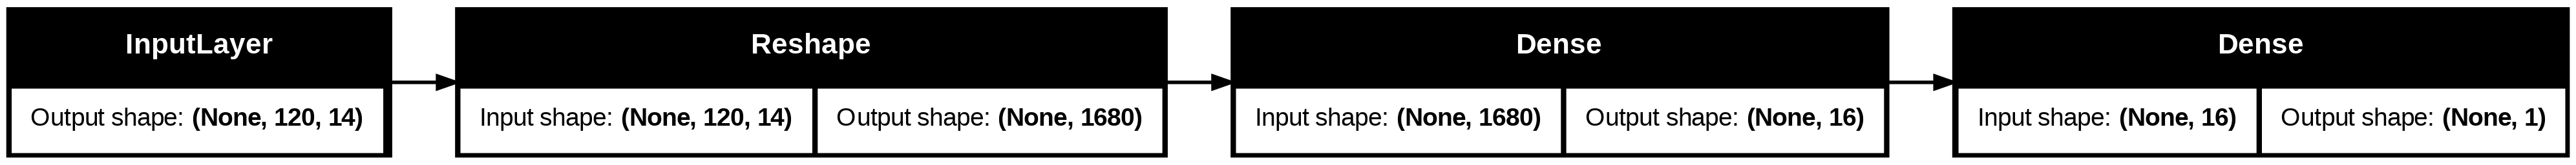

In [15]:
keras.utils.plot_model(model, show_shapes=True, rankdir = 'LR') #the final argument rankdir = 'LR' plots the model horizontally

In [16]:
model = keras.models.load_model("best_baseline.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 11.1061 - mae: 2.6105
Test MAE: 2.62


## Plotting baseline results:

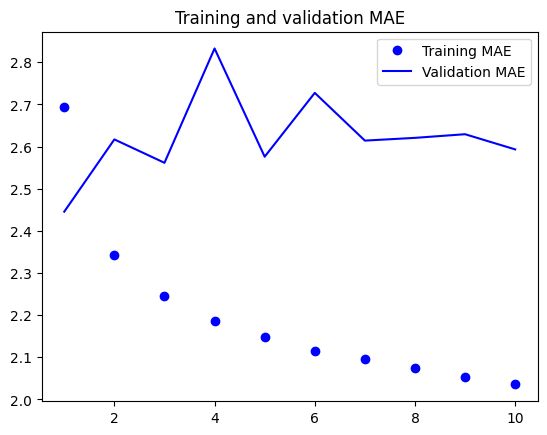

In [17]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()


## Trying a 1D CNN model:

In [18]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("conv1D.keras",
   save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
            epochs=10,
            validation_data=val_dataset,
            callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - loss: 29.3625 - mae: 4.1784 - val_loss: 16.0173 - val_mae: 3.1401
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 15.9329 - mae: 3.1664 - val_loss: 16.4018 - val_mae: 3.1814
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 14.4359 - mae: 3.0098 - val_loss: 16.4846 - val_mae: 3.1908
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 13.6509 - mae: 2.9248 - val_loss: 14.9141 - val_mae: 3.0175
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 12.8879 - mae: 2.8384 - val_loss: 14.5386 - val_mae: 2.9805
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 12.2761 - mae: 2.7707 - val_loss: 14.4801 - val_mae: 2.9743
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 11.8257 - mae: 2.7159 - val_loss: 16.1105 - val_mae: 3.1378
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 11.3835 - mae: 2.6666 - val_loss: 15.5328 - val_mae: 3.1114
Epoch 9/10
819/819 ━━━━━

In [19]:
model = keras.models.load_model("conv1D.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 15.0448 - mae: 3.0756
Test MAE: 3.07


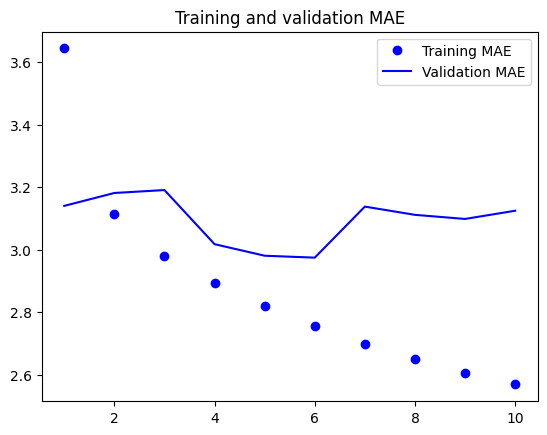

In [20]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

As it turns out, this model performs even worse than the densely connected one,
only achieving a validation MAE of about 3.16 degrees.

## Setting a RNN baseline:
Here we will be using 1 **LSTM** layer as an intermediate layer, LSTM stands for **long-short-term-memory**. We'll understand what the difference between a RNN layer and a dense or convnet layer is after we set this abseline.

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16) (inputs)
outputs = layers.Dense(1) (x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_rnn_baseline.keras",save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history = model.fit(train_dataset,
                   epochs=10,
                   validation_data=val_dataset,
                   callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - loss: 78.1502 - mae: 6.7872 - val_loss: 13.4553 - val_mae: 2.7850
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 12.1871 - mae: 2.6999 - val_loss: 9.9256 - val_mae: 2.4702
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 10.0423 - mae: 2.4748 - val_loss: 10.5993 - val_mae: 2.5114
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 9.5309 - mae: 2.4101 - val_loss: 10.3592 - val_mae: 2.5067
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - loss: 9.1722 - mae: 2.3594 - val_loss: 10.1123 - val_mae: 2.5007
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 8.8638 - mae: 2.3173 - val_loss: 9.9950 - val_mae: 2.4810
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 8.6649 - mae: 2.2905 - val_loss: 10.0854 - val_mae: 2.4785
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 8.5031 - mae: 2.2677 - val_loss: 10.4045 - val_mae: 2.5067
Epoch 9/10
819/819 ━━━━━━━━━━━━

In [23]:
model = keras.models.load_model("best_rnn_baseline.keras") 
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 11.5661 - mae: 2.6504
Test MAE: 2.65


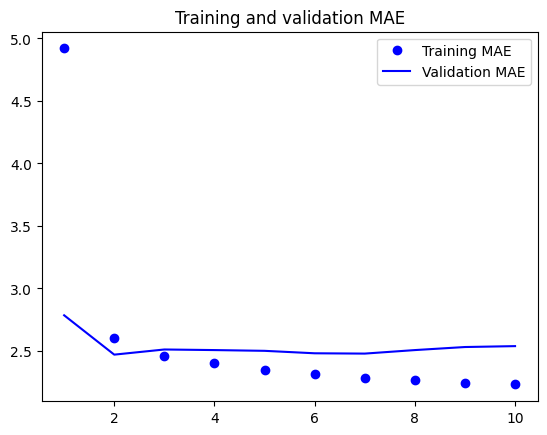

In [24]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

Much better! We achieve a validation MAE as low as 2.36
degrees and a test MAE of 2.65 degrees. The graph speaks it all.

**My conclusion:**
This is because a RNN layer/LSTM layer takes the past states into consideration as well, unlike the DNNs and CNNs which processes each datapoint individually. Here a state is maintained which consists of how past points are changing which alters the current prediction.

**Refined conclusion:**
RNN and LSTM layers process sequential data by maintaining an internal state that carries information from previous timesteps. This allows the model to capture temporal relationships in the data. Unlike DNNs and CNNs, which process each input independently, RNN-based models use past information to influence the current prediction.

Further the results can be improved by following techniques:
* **Recurrent dropout**—This is a variant of dropout, used to fight overfitting in recurrent layers.
* **Stacking recurrent layers**—This increases the representational power of the model
(at the cost of higher computational loads).
* **Bidirectional recurrent layers**—These present the same information to a recurrent
network in different ways, increasing accuracy and mitigating forgetting issues.

## Using recurrent dropouts:
It has long been known that applying dropout before a recurrent layer hinders
learning rather than helping with regularization.

The same dropout mask (the same pattern of dropped units)
should be applied at every timestep, instead of using a dropout mask that varies ran
domly from timestep to timestep.

In [30]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_lstm_dropout.keras",
   save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model.summary()

# history = model.fit(train_dataset,
#             epochs=50,
#             validation_data=val_dataset,
#             callbacks=callbacks)   

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model = keras.models.load_model("best_lstm_dropout.keras") 
# print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Wont run the model due to high computation times on it. Heres the expected results....

We would no longer overfit during the first 20
epochs. We achieve a validation MAE as low as 2.27 degrees (7% improvement over
the no-learning baseline) and a test MAE of 2.45 degrees (6.5% improvement over the
baseline).

Recurrent models with very few parameters, like the ones we are using, tend to
be significantly faster on a multicore CPU than on GPU, because they only involve
small matrix multiplications, and the chain of multiplications is not well paralleliz
able due to the presence of a for loop. But larger RNNs can greatly benefit from a
GPU runtime.

## Stacking recurrent layers:
It’s generally a good idea to
increase the capacity of your model until overfitting becomes the primary obstacle
(assuming you’re already taking basic steps to mitigate overfitting, such as using drop
out). As long as you aren’t overfitting too badly, you’re likely under capacity.

 Increasing network capacity is typically done by increasing the number of units in
the layers or adding more layers. Recurrent layer stacking is a classic way to build
more-powerful recurrent networks.

To stack recurrent layers on top of each other in Keras, all intermediate layers should
return their full sequence of outputs (a rank-3 tensor) rather than their output at the last
timestep.

We'll use **GRU** layers insted of LSTM layers this time. GRU
is very similar to LSTM—you can think of it as a slightly simpler, streamlined version of
the LSTM architecture.

In [31]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("stacked_gru_dropout.keras",
   save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model.summary()

# history = model.fit(train_dataset,
#             epochs=50,
#             validation_data=val_dataset,
#             callbacks=callbacks)

# model = keras.models.load_model("jena_stacked_gru_dropout.keras")
# print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 32)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

wont run the model here either same reasons a above, though heres the expected results...

We would achieve a test MAE of approx 2.39 degrees (an 8.8%
improvement over the baseline). We would see that the added layer does improve the
results a bit, though not dramatically. That means further increase in the capacity will lead to diminishing results.

## Using bidirectional RNNs:
It uses two regular RNNs, such as the GRU and LSTM layers we’re already familiar with,
each of which processes the input sequence in one direction (chronologically and
antichronologically), and then merges their representations. By processing a sequence
both ways, a bidirectional RNN can catch patterns that may be overlooked by a unidi
rectional RNN.

These are used in natural language processing tasks, using them here may lead to underperforming model.

In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model.summary()

history = model.fit(train_dataset,
            epochs=10,
            validation_data=val_dataset)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,001 (15.63 KB)

 Trainable params: 4,001 (15.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - loss: 50.0275 - mae: 5.1877 - val_loss: 10.4713 - val_mae: 2.4968
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 9.8862 - mae: 2.4596 - val_loss: 9.8015 - val_mae: 2.4024
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 8.5513 - mae: 2.2826 - val_loss: 10.0471 - val_mae: 2.4352
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 7.9908 - mae: 2.2060 - val_loss: 10.2197 - val_mae: 2.4725
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 7.6207 - mae: 2.1531 - val_loss: 10.2997 - val_mae: 2.4808
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 7.2530 - mae: 2.1003 - val_loss: 10.5510 - val_mae: 2.5187
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 6.9930 - mae: 2.0632 - val_loss: 10.6173 - val_mae: 2.5197
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 6.6833 - mae: 2.0176 - val_loss: 10.5092 - val_mae: 2.5088
Epoch 9/10
819/819 ━━━━━━━━━━━━━

In [34]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 12.6022 - mae: 2.7910
Test MAE: 2.80


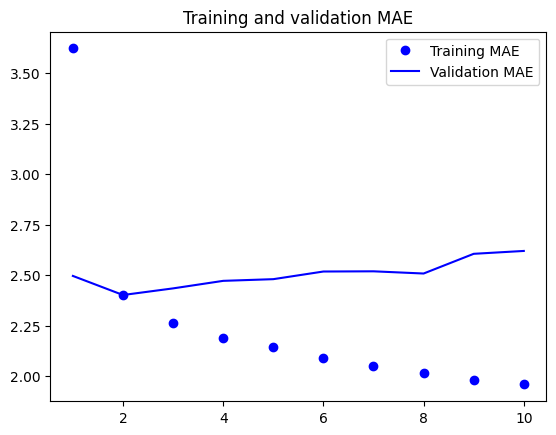

In [35]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

It doesn’t perform as well as the plain LSTM layer. It’s easy to under
stand why: all the predictive capacity must come from the chronological half of the
network, because the antichronological half is known to be severely underperforming
on this task. At the same time, the presence of the antichronological half doubles the
network’s capacity and causes it to start overfitting much earlier.

A really well said thing in the book was.....

"In machine learn
ing, representations that are different yet useful are always worth exploiting, and the
more they differ, the better: they offer a new angle from which to look at your data,
capturing aspects of the data that were missed by other approaches, and thus they
can help boost performance on a task."

 This is the intuition behind ensembling.